****
**Load Tools**

In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt 
plt.style.use("dark_background")
import seaborn as sns
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
nltk.download('wordnet')
nltk.download('stopwords')
import re 
from wordcloud import WordCloud
import warnings
warnings.filterwarnings("ignore")
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import BernoulliNB
from sklearn.metrics import confusion_matrix,classification_report
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping,ModelCheckpoint,ReduceLROnPlateau



[nltk_data] Downloading package wordnet to /usr/share/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
2026-01-30 07:59:52.454315: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1769759992.636093      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1769759992.688053      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1769759993.123945      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:176975

****
**Import Data**

In [2]:
data = pd.read_csv("/kaggle/input/indian-twitter-political-classification-dataset/final_combined_enriched_v4.csv")
data.head()

,tweet,type
0,This cartoon by Alok @caricatured speak about...,1
1,I am going to post one #BernieAtTheFarmersProt...,1
2,@sardesairajdeep @OfficialUrmila @RahulGandhi ...,1
3,Oooh... that`s right by the zoo... think... i...,0
4,@vivekoberoi @narendramodi @OmungKumar @suresh...,1


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50169 entries, 0 to 50168
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   tweet   50169 non-null  object
 1   type    50169 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 784.0+ KB


In [4]:
data.isnull().sum()

tweet    0
type     0
dtype: int64

In [5]:
data.describe()

,type
count,50169.00000
mean,0.54733
std,0.49776
min,0.00000
25%,0.00000
50%,1.00000
75%,1.00000
max,1.00000


In [6]:
data[data.duplicated()].head()

,tweet,type
3110,"While India is a mess, Modi’s priority is the ...",1
3195,@SinghSwaiman On with democracy #FarmersProtes...,1
3669,"@aajtak Blame Gandhi for it but in India, prot...",1
4196,"@aajtak Blame Gandhi for it but in India, prot...",1
4383,What a bimbo 🤦🏻‍♀️ #FarmersProtest twitter.com...,1


****
**EDA**

In [7]:
data.type.value_counts()

type
1    27459
0    22710
Name: count, dtype: int64

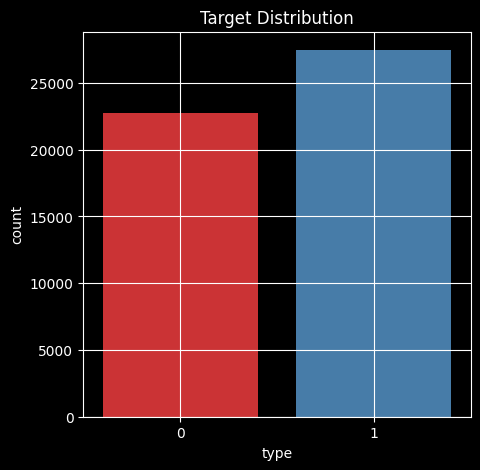

In [8]:
plt.figure(figsize=(5,5))
sns.countplot(x="type",data=data,palette="Set1")
plt.title("Target Distribution",fontsize=12)
plt.grid(True)
plt.show()

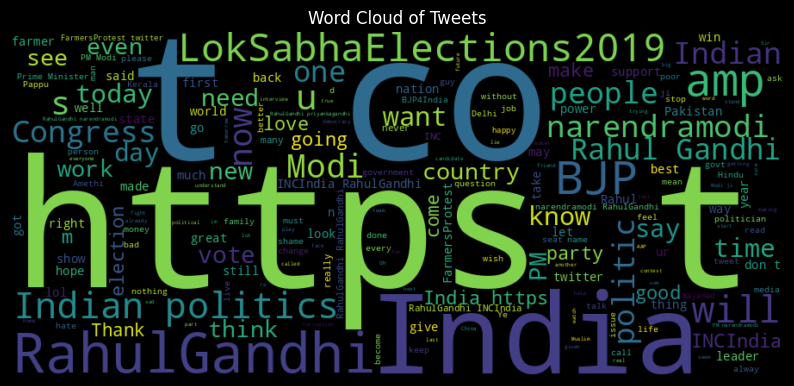

In [9]:
text = " ".join(data['tweet'])
wordcloud = WordCloud(width=900, height=400, background_color='black').generate(text)
plt.figure(figsize=(10,10))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud of Tweets", fontsize=12)
plt.show()

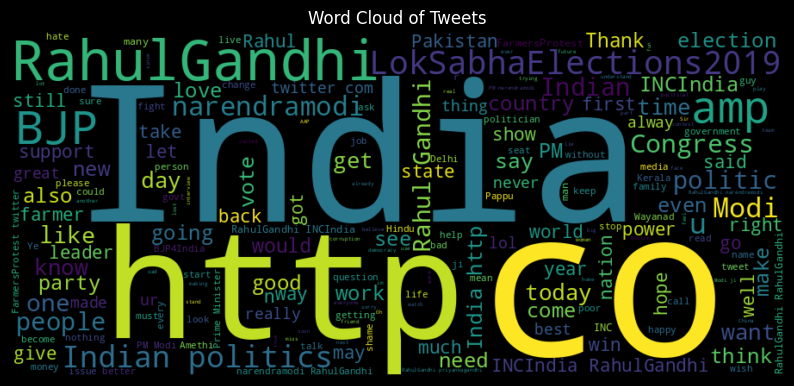

In [10]:
text = " ".join(data['tweet'])
stop_words = set(stopwords.words('english'))
wordcloud = WordCloud(width=900, height=400, background_color='black',stopwords=stop_words).generate(text)
plt.figure(figsize=(10,10))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud of Tweets", fontsize=12)
plt.show()

****
**Preprocessing**

In [11]:
lemmatizer = WordNetLemmatizer()
def preprocess_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    tokens = text.split()
    processed_tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words]
    return " ".join(processed_tokens)
data.tweet = data.tweet.apply(preprocess_text)
data.head()

,tweet,type
0,cartoon alok caricatured speak reality deal in...,1
1,going post one bernieatthefarmersprotest every...,1
2,sardesairajdeep officialurmila rahulgandhi bas...,1
3,oooh thats right zoo think month time could re...,0
4,vivekoberoi narendramodi omungkumar sureshober...,1


In [12]:
X = data.tweet
y = data.type
X.head()

0    cartoon alok caricatured speak reality deal in...
1    going post one bernieatthefarmersprotest every...
2    sardesairajdeep officialurmila rahulgandhi bas...
3    oooh thats right zoo think month time could re...
4    vivekoberoi narendramodi omungkumar sureshober...
Name: tweet, dtype: object

In [13]:
y.head()

0    1
1    1
2    1
3    0
4    1
Name: type, dtype: int64

In [14]:
tfidf_vectorizer = TfidfVectorizer()
X_tfidf = tfidf_vectorizer.fit_transform(X)
X_tfidf

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 700615 stored elements and shape (50169, 83884)>

In [15]:
X_train, X_test, y_train, y_test = train_test_split(X_tfidf, y, test_size=0.2, random_state=42,shuffle=True)
print("Processed Training Data:", X_train.shape)
print("Processed Testing Data:", X_test.shape)

Processed Training Data: (40135, 83884)
Processed Testing Data: (10034, 83884)


****
**ML Models**

LogisticRegression Train Score: 0.9991528591005356
LogisticRegression Test Score: 0.9880406617500498
Confusion Matrix:
[[4504   25]
 [  95 5410]]


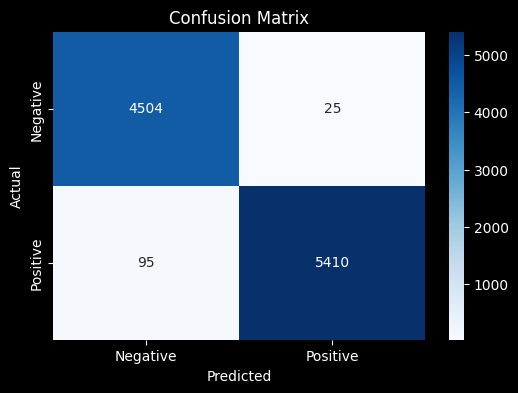


Classification Report:
               precision    recall  f1-score   support

    Negative       0.98      0.99      0.99      4529
    Positive       1.00      0.98      0.99      5505

    accuracy                           0.99     10034
   macro avg       0.99      0.99      0.99     10034
weighted avg       0.99      0.99      0.99     10034



In [16]:
log = LogisticRegression(C=1000)
log.fit(X_train,y_train)
y_pred = log.predict(X_test)
print(f"LogisticRegression Train Score: {log.score(X_train,y_train)}")
print(f"LogisticRegression Test Score: {log.score(X_test,y_test)}")
cm = confusion_matrix(y_test,y_pred)
print("Confusion Matrix:")
print(cm)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])
plt.title("Confusion Matrix")
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()
print("\nClassification Report:\n",classification_report(y_test,y_pred,target_names=['Negative', 'Positive']))

RandomForestClassifier Train Score: 1.0
RandomForestClassifier Test Score: 0.9891369344229619
Confusion Matrix:
[[4477   52]
 [  57 5448]]


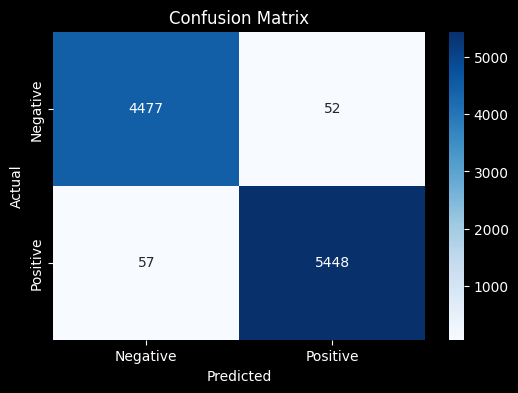


Classification Report:
               precision    recall  f1-score   support

    Negative       0.99      0.99      0.99      4529
    Positive       0.99      0.99      0.99      5505

    accuracy                           0.99     10034
   macro avg       0.99      0.99      0.99     10034
weighted avg       0.99      0.99      0.99     10034



In [17]:
random = RandomForestClassifier()
random.fit(X_train,y_train)
y_pred = random.predict(X_test)
print(f"RandomForestClassifier Train Score: {random.score(X_train,y_train)}")
print(f"RandomForestClassifier Test Score: {random.score(X_test,y_test)}")
cm = confusion_matrix(y_test,y_pred)
print("Confusion Matrix:")
print(cm)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])
plt.title("Confusion Matrix")
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()
print("\nClassification Report:\n",classification_report(y_test,y_pred,target_names=['Negative', 'Positive']))

BernoulliNB Train Score: 0.982160209293634
BernoulliNB Test Score: 0.9705002989834562
Confusion Matrix:
[[4401  128]
 [ 168 5337]]


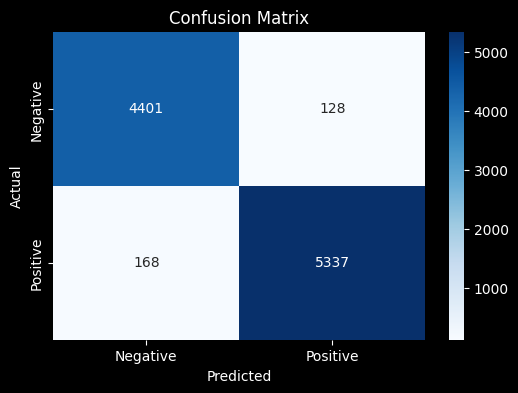


Classification Report:
               precision    recall  f1-score   support

    Negative       0.96      0.97      0.97      4529
    Positive       0.98      0.97      0.97      5505

    accuracy                           0.97     10034
   macro avg       0.97      0.97      0.97     10034
weighted avg       0.97      0.97      0.97     10034



In [18]:
nb = BernoulliNB(alpha=1)
nb.fit(X_train,y_train)
y_pred = nb.predict(X_test)
print(f"BernoulliNB Train Score: {nb.score(X_train,y_train)}")
print(f"BernoulliNB Test Score: {nb.score(X_test,y_test)}")
cm = confusion_matrix(y_test,y_pred)
print("Confusion Matrix:")
print(cm)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])
plt.title("Confusion Matrix")
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()
print("\nClassification Report:\n",classification_report(y_test,y_pred,target_names=['Negative', 'Positive']))